# Symplectic Integration of the Ideal Pendulum

An *undamped, unforced* pendulum is a conservative system: with no friction and
no driving force, its total mechanical energy is fixed for all time. That single
fact is a demanding test for a numerical integrator. If the method quietly adds
or removes energy on every step, the simulated pendulum will slowly wind up or
wind down even though the real one never does.

This notebook walks through four integrators of increasing quality, all applied
to the same pendulum released from rest at $\theta_0 = 45^\circ$:

1. **Velocity Verlet** and **Yoshida 4th-order** - two *symplectic* methods whose
   angle-vs-time traces stay clean and steady, just like the Euler-Cromer result
   from Session 18 (`cromer_pendulum.ipynb`).
2. **Phase space** ($\omega$ vs $\theta$) - where the difference between methods
   becomes obvious: Forward Euler spirals outward, Euler-Cromer wobbles around the
   true loop, and Verlet and Yoshida trace the exact energy contour almost perfectly.
3. **FFT power spectra** - a frequency-domain view showing how a cleaner integrator
   produces a purer spectral peak and a smaller long-term energy error.

The exact (nonlinear) equation of motion is used throughout - no small-angle
approximation:

$$\alpha = \ddot{\theta} = -\frac{g}{L}\sin\theta.$$

Everything the notebook needs is defined locally in the next two cells, so it
runs stand-alone.

---
## Setup: pendulum physics

We fix the physical constants ($L = 1\ \text{m}$, $g = 9.81\ \text{m/s}^2$) and
define two helper functions used by every integrator below:

- `pendulum_angular_acceleration(theta)` returns $\alpha = -\frac{g}{L}\sin\theta$.
- `pendulum_total_energy(theta, omega)` returns the energy **per unit mass**,
  $E = \tfrac{1}{2}\omega^2 - \tfrac{g}{L}\cos\theta$, referenced to the pivot.
  For a conservative pendulum this quantity should stay constant.

In [1]:
"""pendulums.ipynb"""

# Cell 01 - Imports and pendulum physics

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
from numpy.fft import fft
from scipy.integrate import solve_ivp

# Physical constants for an ideal simple pendulum
PENDULUM_LENGTH = 1.0  # pendulum length (m)
PENDULUM_G = 9.81  # gravitational acceleration (m/s^2)


def pendulum_angular_acceleration(
    theta: float | np.ndarray,
) -> float | np.ndarray:
    """Angular acceleration of an ideal pendulum: alpha = -(g/L) sin(theta)."""
    return -PENDULUM_G / PENDULUM_LENGTH * np.sin(theta)


def pendulum_total_energy(
    theta: float | np.ndarray, omega: float | np.ndarray
) -> float | np.ndarray:
    """Total mechanical energy per unit mass: E = (1/2) omega^2 - (g/L) cos(theta)."""
    return 0.5 * omega**2 - PENDULUM_G / PENDULUM_LENGTH * np.cos(theta)


# Quick check that the helpers work at a known point
theta_test = np.deg2rad(45)
print(f"alpha(45 deg)   = {pendulum_angular_acceleration(theta_test):+.4f} rad/s^2")
print(f"E(45 deg, 0)    = {pendulum_total_energy(theta_test, 0.0):+.4f} J/kg")
print(f"(expected alpha = {-PENDULUM_G / PENDULUM_LENGTH * np.sin(theta_test):+.4f})")

alpha(45 deg)   = -6.9367 rad/s^2
E(45 deg, 0)    = -6.9367 J/kg
(expected alpha = -6.9367)


---
## Setup: the four integrators

Each integrator takes the same signature `(theta0, omega0, t_final, dt)` and
returns arrays `(t, theta, omega)`. They differ only in *how* they step forward:

| Method | Order | Symplectic? | Behavior |
|---|---|---|---|
| **Forward Euler** | 1 | No | Uses stale velocity; injects energy, spirals outward |
| **Euler-Cromer** | 1 | Yes | Uses freshly updated velocity; energy wobbles but does not drift |
| **Velocity Verlet** | 2 | Yes | Averages acceleration over the step; hugs the true energy contour |
| **Yoshida 4th-order** | 4 | Yes | Composes three Verlet substeps to cancel lower-order error |

We also include **RK45** (SciPy's adaptive Runge-Kutta) as a high-order but
*non*-symplectic reference for the FFT section.

The Yoshida coefficients come from Yoshida (1990), *Construction of higher order
symplectic integrators*. The middle substep steps **backward** in time (negative
coefficient) to cancel the second-order error left by a single Verlet step.

In [2]:
# Cell 02 - Symplectic and reference integrators


def solve_forward_euler(theta0, omega0, t_final, dt):
    """Forward Euler (1st order, non-symplectic): position uses the OLD velocity."""
    n_steps = int(t_final / dt)
    t = np.arange(n_steps) * dt
    theta = np.zeros(n_steps)
    omega = np.zeros(n_steps)
    theta[0], omega[0] = theta0, omega0
    for i in range(n_steps - 1):
        alpha = pendulum_angular_acceleration(theta[i])
        omega[i + 1] = omega[i] + alpha * dt
        theta[i + 1] = theta[i] + omega[i] * dt  # uses stale omega[i]
    return t, theta, omega


def pendulum_euler_cromer(theta0, omega0, t_final, dt):
    """Euler-Cromer (1st order, symplectic): position uses the NEW velocity."""
    n_steps = int(t_final / dt)
    t = np.arange(n_steps) * dt
    theta = np.zeros(n_steps)
    omega = np.zeros(n_steps)
    theta[0], omega[0] = theta0, omega0
    for i in range(n_steps - 1):
        alpha = pendulum_angular_acceleration(theta[i])
        omega[i + 1] = omega[i] + alpha * dt
        theta[i + 1] = theta[i] + omega[i + 1] * dt  # Cromer's fix
    return t, theta, omega


def pendulum_velocity_verlet(theta0, omega0, t_final, dt):
    """Velocity Verlet (2nd order, symplectic): average of start/end acceleration."""
    n_steps = int(t_final / dt)
    t = np.arange(n_steps) * dt
    theta = np.zeros(n_steps)
    omega = np.zeros(n_steps)
    theta[0], omega[0] = theta0, omega0
    for i in range(n_steps - 1):
        alpha = pendulum_angular_acceleration(theta[i])
        theta[i + 1] = theta[i] + omega[i] * dt + 0.5 * alpha * dt**2
        alpha_new = pendulum_angular_acceleration(theta[i + 1])
        omega[i + 1] = omega[i] + 0.5 * (alpha + alpha_new) * dt
    return t, theta, omega


def yoshida_coeffs():
    """Position (c) and velocity (d) substep coefficients for Yoshida 4th order."""
    cbrt2 = 2.0 ** (1.0 / 3.0)
    w1 = 1.0 / (2.0 - cbrt2)
    w0 = -cbrt2 / (2.0 - cbrt2)
    c = np.array([w1 / 2.0, (w0 + w1) / 2.0, (w0 + w1) / 2.0, w1 / 2.0])
    d = np.array([w1, w0, w1])
    return c, d


def pendulum_yoshida4(theta0, omega0, t_final, dt):
    """Yoshida 4th order (symplectic): three weighted Verlet substeps per step."""
    c, d = yoshida_coeffs()
    n_steps = int(t_final / dt)
    t = np.arange(n_steps) * dt
    theta = np.zeros(n_steps)
    omega = np.zeros(n_steps)
    theta[0], omega[0] = theta0, omega0
    for i in range(n_steps - 1):
        th, om = theta[i], omega[i]
        for j in range(3):
            th += c[j] * om * dt
            om += d[j] * pendulum_angular_acceleration(th) * dt
        th += c[3] * om * dt
        theta[i + 1], omega[i + 1] = th, om
    return t, theta, omega


def _ode_model(time, state_vector):
    """State-space form (omega, theta) for solve_ivp."""
    omega, theta = state_vector
    return pendulum_angular_acceleration(theta), omega


def solve_rk45(theta0, omega0, t_final, dt):
    """SciPy adaptive RK45 (high order, NOT symplectic) - our reference solver."""
    sol = solve_ivp(
        _ode_model,
        (0, t_final),
        [omega0, theta0],
        method="RK45",
        max_step=dt,
        dense_output=True,
    )
    t = np.arange(0, t_final, dt)
    y = sol.sol(t)
    return t, y[1], y[0]  # t, theta, omega


# Quick check: a short Verlet run should conserve energy to high precision
t, th, om = pendulum_velocity_verlet(np.deg2rad(45), 0.0, 10, 0.02)
E0 = pendulum_total_energy(th[0], om[0])
Ef = pendulum_total_energy(th[-1], om[-1])
print(f"Verlet 10s check: E0 = {E0:.6f}, Ef = {Ef:.6f}, drift = {Ef - E0:+.2e} J/kg")

Verlet 10s check: E0 = -6.936718, Ef = -6.939233, drift = -2.52e-03 J/kg


---
# Part 1 - The Oscillations (angle and velocity vs time)

We first reproduce the familiar time-domain picture from Session 18's
`cromer_pendulum.ipynb`, but now using the two **higher-order symplectic**
methods. The pendulum is released from rest at $\theta_0 = 45^\circ$ and
integrated for 10 seconds with 500 steps ($\Delta t = 0.02\ \text{s}$), exactly
matching the Euler and Euler-Cromer notebooks so the plots line up.

For a conservative pendulum the angle $\theta$ and angular velocity $\omega$ should
trace steady, repeating oscillations - the amplitude must not creep upward
(Forward Euler's failure) or decay. We print the energy drift so you can see just
how flat these methods keep the energy.

## Velocity Verlet oscillations

Velocity Verlet is 2nd-order accurate. It advances the angle using the current
acceleration, then corrects the velocity with the **average** of the accelerations
at the start and end of the step. That averaging is what makes it symplectic and
keeps the amplitude locked in.

Initial energy :  2.873 J
Final energy   :  2.871 J
Energy drift   : -0.003 J  (-0.088%)


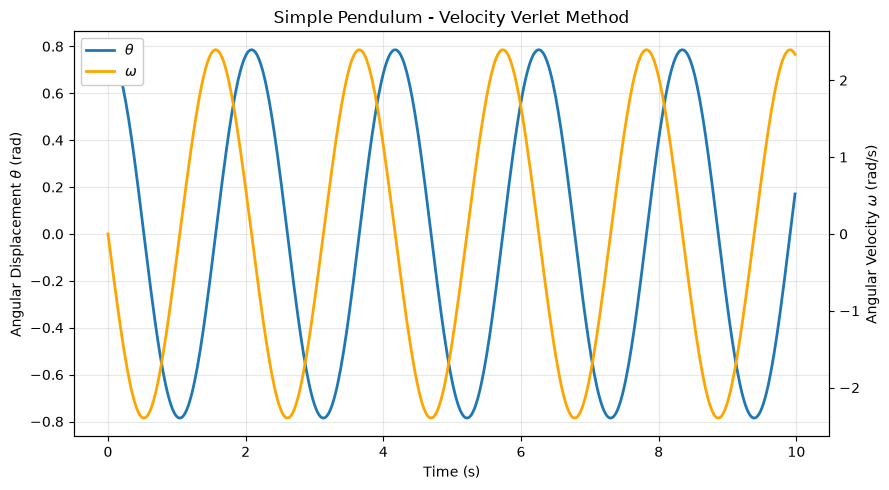

In [3]:
# Cell 03 - Velocity Verlet: oscillations and energy drift

theta0 = np.deg2rad(45)  # initial angle (radians)
omega0 = 0.0  # released from rest
tf = 10  # final time (s)
dt = tf / 500  # 500 steps, 20 ms each

mass = 1.0  # pendulum bob mass (kg)
length = 1.0  # pendulum length (m)
g = 9.81  # gravitational acceleration (m/s^2)

t, theta, omega = pendulum_velocity_verlet(theta0, omega0, tf, dt)

# Energy in joules (E = (1/2) m L^2 omega^2 + m g L (1 - cos theta))
Ei = 0.5 * mass * length**2 * omega[0] ** 2 + mass * g * length * (1 - np.cos(theta[0]))
Ef = 0.5 * mass * length**2 * omega[-1] ** 2 + mass * g * length * (1 - np.cos(theta[-1]))
drift_pct = 100 * (Ef - Ei) / Ei
print(f"Initial energy : {Ei:6.3f} J")
print(f"Final energy   : {Ef:6.3f} J")
print(f"Energy drift   : {Ef - Ei:6.3f} J  ({drift_pct:6.3f}%)")

fig, ax1 = plt.subplots(figsize=(9, 5))
(plot1,) = ax1.plot(t, theta, lw=2, label=r"$\theta$ (rad)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel(r"Angular Displacement $\theta$ (rad)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
(plot2,) = ax2.plot(t, omega, lw=2, color="orange", label=r"$\omega$ (rad/s)")
ax2.set_ylabel(r"Angular Velocity $\omega$ (rad/s)")

plt.title("Simple Pendulum - Velocity Verlet Method")
plt.legend(
    [plot1, plot2], [r"$\theta$", r"$\omega$"], framealpha=1.0, facecolor="white"
)
plt.tight_layout()
plt.show()

## Yoshida 4th-order oscillations

Yoshida's method composes three Verlet-like substeps per step with carefully
chosen weights, cancelling the leading error terms and reaching **4th-order**
accuracy. On this 10-second run the time-domain plot looks essentially identical
to Verlet - the two methods only pull apart over very long integrations or in the
phase-space and spectral views that follow. The energy drift, however, is even
smaller.

Initial energy :  2.873 J
Final energy   :  2.873 J
Energy drift   : -0.000 J  (-0.000%)


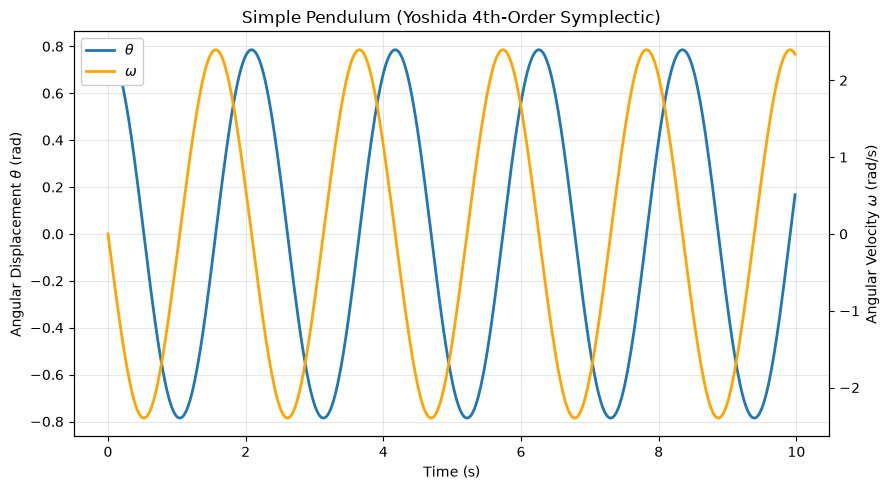

In [4]:
# Cell 04 - Yoshida 4th-order: oscillations and energy drift

t, theta, omega = pendulum_yoshida4(theta0, omega0, tf, dt)

Ei = 0.5 * mass * length**2 * omega[0] ** 2 + mass * g * length * (1 - np.cos(theta[0]))
Ef = 0.5 * mass * length**2 * omega[-1] ** 2 + mass * g * length * (1 - np.cos(theta[-1]))
drift_pct = 100 * (Ef - Ei) / Ei
print(f"Initial energy : {Ei:6.3f} J")
print(f"Final energy   : {Ef:6.3f} J")
print(f"Energy drift   : {Ef - Ei:6.3f} J  ({drift_pct:6.3f}%)")

fig, ax1 = plt.subplots(figsize=(9, 5))
(plot1,) = ax1.plot(t, theta, lw=2, label=r"$\theta$ (rad)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel(r"Angular Displacement $\theta$ (rad)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
(plot2,) = ax2.plot(t, omega, lw=2, color="orange", label=r"$\omega$ (rad/s)")
ax2.set_ylabel(r"Angular Velocity $\omega$ (rad/s)")

plt.title("Simple Pendulum (Yoshida 4th-Order Symplectic)")
plt.legend(
    [plot1, plot2], [r"$\theta$", r"$\omega$"], framealpha=1.0, facecolor="white"
)
plt.tight_layout()
plt.show()

---
# Part 2 - Phase Space (the real test)

The time-domain plots above all look reasonable over 10 seconds. To see which
methods are *actually* conserving energy, we plot the trajectory in **phase
space**: angular velocity $\omega$ on the vertical axis versus angle $\theta$ on
the horizontal axis.

For a conservative pendulum, energy conservation

$$E = \tfrac{1}{2}\omega^2 - \tfrac{g}{L}\cos\theta = E_0$$

forces the trajectory onto a single **closed loop** - the exact energy contour.
The pendulum returns to the same state every period, tracing the same oval
forever. Any method that gains or loses energy will drift *off* that loop:

- **Forward Euler** spirals steadily **outward** (energy grows without bound).
  We run it for only 20 s because it blows up quickly.
- **Euler-Cromer** stays near the loop but visibly **wobbles** around it.
- **Velocity Verlet** and **Yoshida** hug the exact contour so tightly that after
  **500 seconds** they are still indistinguishable from the black dashed curve.

The exact contour is drawn last (on top) from the analytic turning angle
$\theta_{\max} = \arccos(-E_0 L / g)$, where $\omega = 0$.

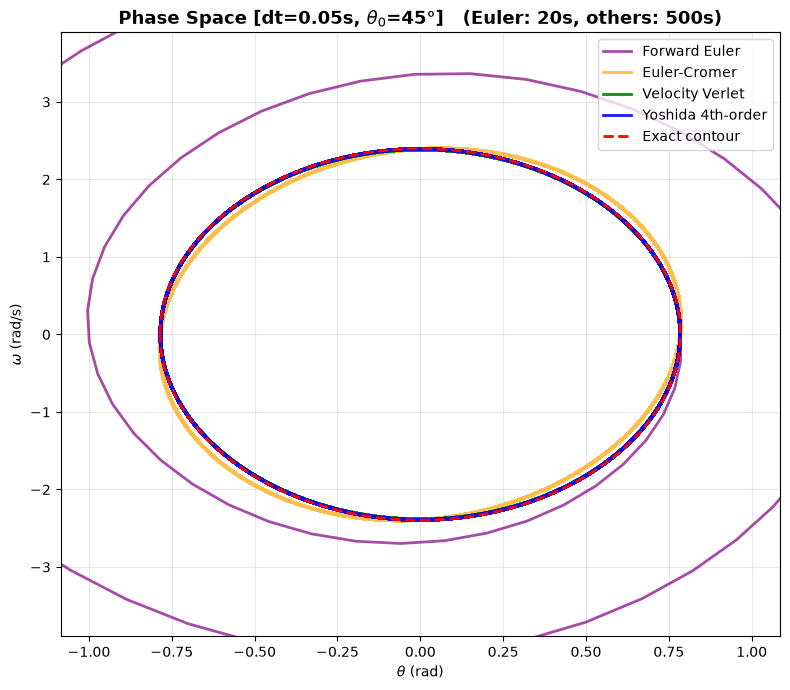


E0 = -6.936718 J/kg
Method                  t_run (s)      Final E        Drift    Drift %
----------------------------------------------------------------------
Forward Euler                  20    40.743887   +47.680604  +687.3655%
Euler-Cromer                  500    -6.746346    +0.190372    +2.7444%
Velocity Verlet               500    -6.944606    -0.007889    -0.1137%
Yoshida 4th-order             500    -6.936734    -0.000017    -0.0002%


In [5]:
# Cell 05 - Phase space comparison of all four integrators


def exact_contour(E0, n_points=1000):
    """Closed phase-space loop omega(theta) for a given energy E0."""
    theta_max = np.arccos(-E0 * PENDULUM_LENGTH / PENDULUM_G)
    theta_valid = np.linspace(-theta_max, theta_max, n_points)
    omega_sq = 2.0 * (E0 + (PENDULUM_G / PENDULUM_LENGTH) * np.cos(theta_valid))
    omega_upper = np.sqrt(np.maximum(omega_sq, 0.0))
    omega_lower = -omega_upper
    # Stitch into one closed loop: forward along top, backward along bottom
    theta_closed = np.concatenate([theta_valid, theta_valid[::-1]])
    omega_closed = np.concatenate([omega_upper, omega_lower[::-1]])
    return theta_closed, omega_closed


theta_initial = np.deg2rad(45)
omega_initial = 0.0
dt_ps = 0.05
t_symplectic = 500  # seconds for the symplectic methods
t_euler = 20  # Forward Euler blows up fast, so run it briefly

E0 = pendulum_total_energy(theta_initial, omega_initial)

methods = {
    "Forward Euler": (solve_forward_euler, "purple", 0.7, t_euler),
    "Euler-Cromer": (pendulum_euler_cromer, "orange", 0.7, t_symplectic),
    "Velocity Verlet": (pendulum_velocity_verlet, "green", 0.9, t_symplectic),
    "Yoshida 4th-order": (pendulum_yoshida4, "blue", 0.9, t_symplectic),
}

results = {}
for name, (solver, color, alpha, t_run) in methods.items():
    t, theta, omega = solver(theta_initial, omega_initial, t_run, dt_ps)
    results[name] = (t, theta, omega, color, alpha)

theta_exact, omega_exact = exact_contour(E0)

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
for name in methods:
    t, theta, omega, color, alpha = results[name]
    ax.plot(theta, omega, color=color, linewidth=2, alpha=alpha, label=name)
ax.plot(theta_exact, omega_exact, "r--", lw=2, label="Exact contour")

pad = 0.3
ax.set_xlim(theta_exact.min() - pad, theta_exact.max() + pad)
ax.set_ylim(omega_exact.min() - 1.5, omega_exact.max() + 1.5)
ax.set_title(
    f"Phase Space [dt={dt_ps}s, "
    rf"$\theta_0$={np.rad2deg(theta_initial):.0f}°]"
    f"   (Euler: {t_euler}s, others: {t_symplectic}s)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\omega$ (rad/s)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# Energy drift summary
print(f"\nE0 = {E0:.6f} J/kg")
print(f"{'Method':<22} {'t_run (s)':>10} {'Final E':>12} {'Drift':>12} {'Drift %':>10}")
print("-" * 70)
for name in methods:
    t, theta, omega, color, alpha = results[name]
    E_final = pendulum_total_energy(theta[-1], omega[-1])
    drift = E_final - E0
    drift_pct = 100 * drift / abs(E0)
    print(
        f"{name:<22} {t[-1]:>10.0f} {E_final:>12.6f} {drift:>+12.6f} {drift_pct:>+10.4f}%"
    )

---
# Part 3 - Frequency Domain (FFT power spectra)

A third way to judge an integrator is to look at the **frequency content** of the
angle signal $\theta(t)$ over a long run. A perfectly periodic pendulum should
produce a single razor-sharp spectral peak at its natural frequency. Numerical
error smears or shifts that peak and raises the noise floor.

For each method we plot two panels side by side:

- **Left:** the relative energy error $|E - E_0| / |E_0|$ over time (log scale).
- **Right:** the FFT power spectrum of $\theta(t)$ in decibels.

We drop the release angle to $\theta_0 = 10^\circ$ (closer to the small-angle
regime) and integrate for **2000 s** at $\Delta t = 0.02\ \text{s}$ (50 Hz
sampling) - a shorter run than the original script, but still long enough to
resolve the fundamental sharply.

**Amplitude-to-dB check:** a sinusoid of amplitude $A$ produces a peak at exactly
$20\log_{10}(A)$ dB. For a $10^\circ$ swing, $A = 0.1745$ rad, so
$20\log_{10}(0.1745) \approx -15.2$ dB - watch for the peak near that height.

The next cell runs all four integrators once and stores the results; the four
cells after it each plot one method.

In [6]:
# Cell 06 - Run the four integrators and compute spectra for the FFT study


def compute_spectrum(theta, dt):
    """Normalized one-sided FFT amplitude spectrum and frequency axis (Hz)."""
    n = len(theta)
    ct = 2 / n * fft(theta)
    ct[0] /= 2  # DC value should NOT be doubled
    freqs = np.arange(n) / (n * dt)
    power = np.abs(ct)
    power_db = 20 * np.log10(np.maximum(power, 1e-15))
    return freqs, power, power_db


def plot_energy_error(ax, t, abs_energy_error, color):
    """Plot |E - E0| / |E0| over time on a log scale."""
    ax.plot(t, abs_energy_error, color=color, linewidth=0.3)
    ax.set_yscale("log")
    ax.set_title("|Energy Error|")
    ax.set_xlabel("time (s)", loc="right")
    ax.set_ylabel("|E - E0| / |E0|")
    ax.grid(True, alpha=0.3, which="both")


def plot_power_spectrum(ax, freqs, power_db, color, f_max=3.0):
    """Plot the FFT power spectrum in dB up to f_max Hz."""
    mask = (freqs > 0) & (freqs <= f_max)
    ax.plot(freqs[mask], power_db[mask], color=color, linewidth=0.8)
    ax.grid(which="major", axis="x", color="black", linewidth=1)
    ax.grid(which="minor", axis="x", color="lightgray", linewidth=1)
    ax.grid(which="major", axis="y", color="black", linewidth=1)
    ax.grid(which="minor", axis="y", color="lightgray", linewidth=1)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_title("Power Spectrum")
    ax.set_xlabel("frequency (Hz)", loc="right")
    ax.set_ylabel("power (dB)")


# Simulation parameters for the spectral study
theta_fft = np.deg2rad(10)
omega_fft = 0.0
dt_fft = 0.02  # 50 Hz sample rate
t_final_fft = 2000  # seconds - trimmed from 10000 so the notebook runs quickly

E0_fft = pendulum_total_energy(theta_fft, omega_fft)
f_natural = 1.0 / (2.0 * np.pi) * np.sqrt(PENDULUM_G / PENDULUM_LENGTH)

fft_methods = {
    "RK45 (solve_ivp)": (solve_rk45, "red"),
    "Euler-Cromer": (pendulum_euler_cromer, "orange"),
    "Velocity Verlet": (pendulum_velocity_verlet, "green"),
    "Yoshida 4th-Order": (pendulum_yoshida4, "blue"),
}

# Shared axis limits across all four figures
err_ylim = (1e-10, 1e0)
db_min, db_max = -100, 10

fft_results = {}
for name, (solver, color) in fft_methods.items():
    print(f"Running {name}...")
    t, theta, omega = solver(theta_fft, omega_fft, t_final_fft, dt_fft)
    E = pendulum_total_energy(theta, omega)
    abs_energy_error = np.maximum(np.abs((E - E0_fft) / abs(E0_fft)), 1e-16)
    freqs, power, power_db = compute_spectrum(theta, dt_fft)
    fft_results[name] = (t, abs_energy_error, freqs, power, power_db, color)

# Summary table
print(f"\nExpected fundamental ~ {f_natural:.4f} Hz (small-angle approx)")
print(
    f"{'Method':<22} {'Peak (Hz)':>10} {'Peak (dB)':>10}"
    f" {'Energy err std':>16} {'Energy err max':>16}"
)
print("-" * 78)
for name in fft_methods:
    t, abs_energy_error, freqs, power, power_db, color = fft_results[name]
    mask = (freqs > 0.1) & (freqs < 2.0)
    idx_peak = np.argmax(power[mask])
    print(
        f"{name:<22} {freqs[mask][idx_peak]:>10.4f} {power_db[mask][idx_peak]:>10.1f}"
        f" {np.std(abs_energy_error):>16.2e} {np.max(abs_energy_error):>16.2e}"
    )

Running RK45 (solve_ivp)...


Running Euler-Cromer...
Running Velocity Verlet...
Running Yoshida 4th-Order...



Expected fundamental ~ 0.4985 Hz (small-angle approx)
Method                  Peak (Hz)  Peak (dB)   Energy err std   Energy err max
------------------------------------------------------------------------------
RK45 (solve_ivp)           0.4975      -15.2         1.47e-08         5.08e-08
Euler-Cromer               0.4975      -16.0         1.49e-04         4.98e-04
Velocity Verlet            0.4975      -16.0         5.34e-06         1.51e-05
Yoshida 4th-Order          0.4975      -15.2         6.21e-09         1.76e-08


## RK45 spectrum (high-order, but not symplectic)

RK45 is very accurate step-to-step, but because it is **not** symplectic its
energy error grows steadily with time (watch the left panel climb). The spectral
peak is still sharp, yet the rising energy error is the tell-tale sign of a
non-conservative method.

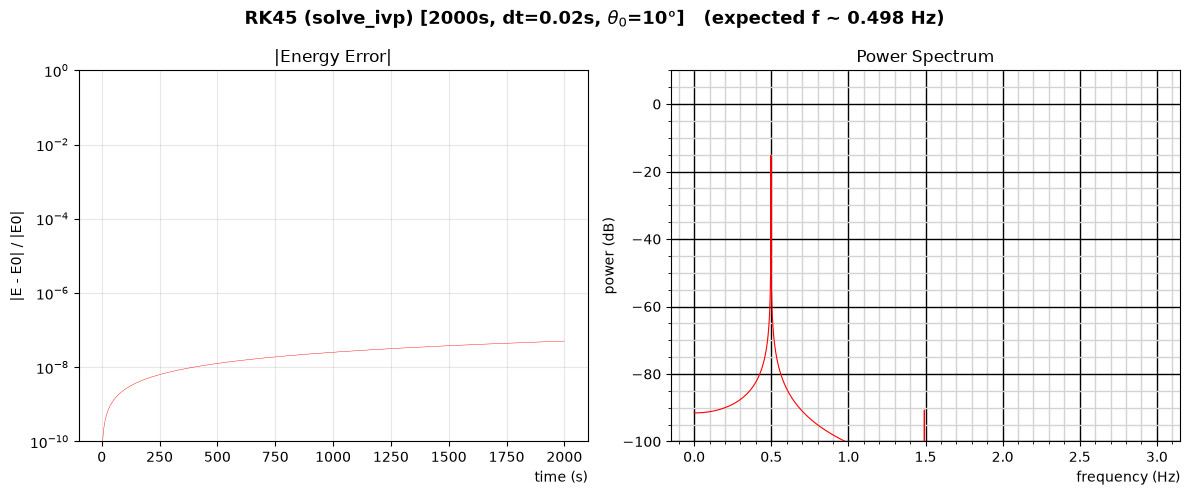

In [7]:
# Cell 07 - RK45 energy error and power spectrum

name = "RK45 (solve_ivp)"
t, abs_energy_error, freqs, power, power_db, color = fft_results[name]

fig, (ax_err, ax_fft) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"{name} [{t_final_fft}s, dt={dt_fft}s, "
    rf"$\theta_0$={np.rad2deg(theta_fft):.0f}°]"
    f"   (expected f ~ {f_natural:.3f} Hz)",
    fontsize=13,
    fontweight="bold",
)
plot_energy_error(ax_err, t, abs_energy_error, color)
ax_err.set_ylim(err_ylim)
plot_power_spectrum(ax_fft, freqs, power_db, color)
ax_fft.set_ylim(db_min, db_max)
fig.tight_layout()
plt.show()

## Euler-Cromer spectrum (1st-order symplectic)

Euler-Cromer conserves energy *on average*, so its energy error stays **bounded**
(a flat band rather than a rising ramp) - already a qualitative improvement over
RK45. Being only 1st-order, its band sits relatively high and the spectral peak
carries the most numerical broadening of the three symplectic methods.

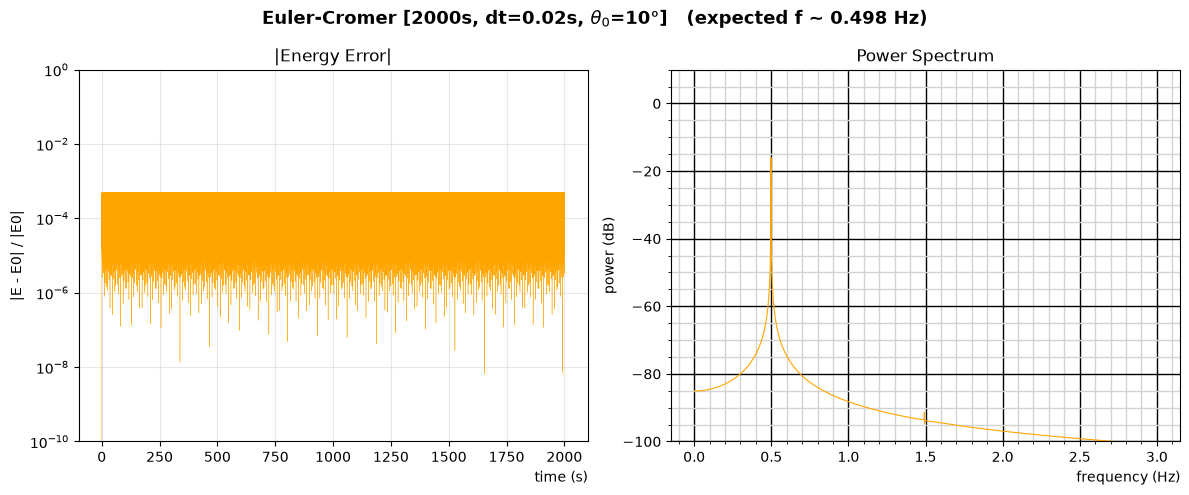

In [8]:
# Cell 08 - Euler-Cromer energy error and power spectrum

name = "Euler-Cromer"
t, abs_energy_error, freqs, power, power_db, color = fft_results[name]

fig, (ax_err, ax_fft) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"{name} [{t_final_fft}s, dt={dt_fft}s, "
    rf"$\theta_0$={np.rad2deg(theta_fft):.0f}°]"
    f"   (expected f ~ {f_natural:.3f} Hz)",
    fontsize=13,
    fontweight="bold",
)
plot_energy_error(ax_err, t, abs_energy_error, color)
ax_err.set_ylim(err_ylim)
plot_power_spectrum(ax_fft, freqs, power_db, color)
ax_fft.set_ylim(db_min, db_max)
fig.tight_layout()
plt.show()

## Velocity Verlet spectrum (2nd-order symplectic)

Verlet's bounded energy band drops well below Euler-Cromer's, and its spectral
peak is noticeably cleaner. Doubling the order of accuracy pushes the energy
error down by orders of magnitude at the same step size.

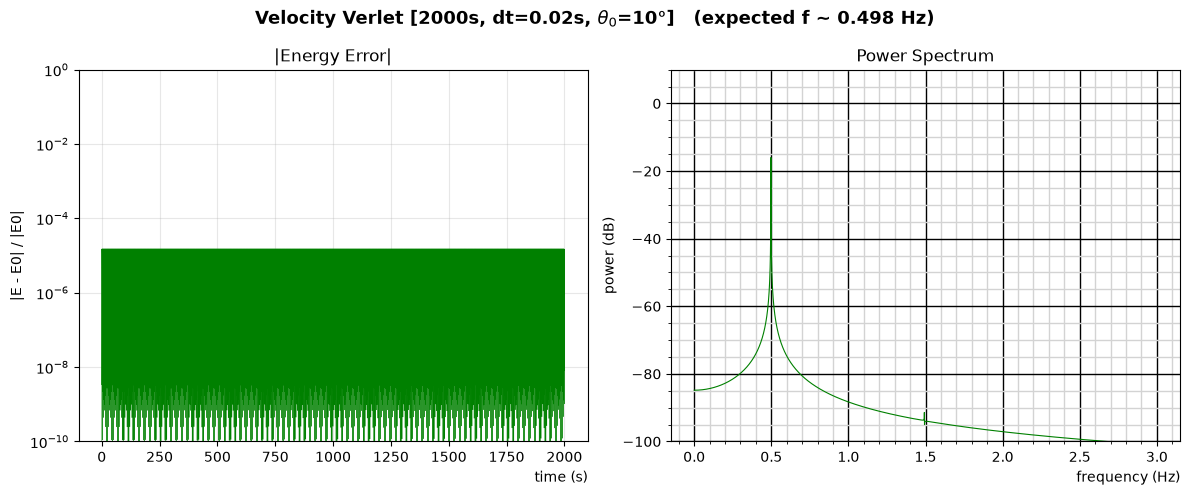

In [9]:
# Cell 09 - Velocity Verlet energy error and power spectrum

name = "Velocity Verlet"
t, abs_energy_error, freqs, power, power_db, color = fft_results[name]

fig, (ax_err, ax_fft) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"{name} [{t_final_fft}s, dt={dt_fft}s, "
    rf"$\theta_0$={np.rad2deg(theta_fft):.0f}°]"
    f"   (expected f ~ {f_natural:.3f} Hz)",
    fontsize=13,
    fontweight="bold",
)
plot_energy_error(ax_err, t, abs_energy_error, color)
ax_err.set_ylim(err_ylim)
plot_power_spectrum(ax_fft, freqs, power_db, color)
ax_fft.set_ylim(db_min, db_max)
fig.tight_layout()
plt.show()

## Yoshida 4th-order spectrum (the cleanest)

Yoshida's 4th-order method gives the lowest energy-error band and the purest
spectral peak of all four - the noise floor around the fundamental is the
quietest here. This is the pay-off for composing three Verlet substeps per step:
dramatically better long-term fidelity for the same step size.

**Takeaway:** for conservative systems, a *symplectic* integrator matters far more
than raw per-step accuracy. RK45 is high-order yet leaks energy; the symplectic
family keeps energy bounded, and each increase in symplectic order tightens the
phase-space loop and sharpens the spectrum.

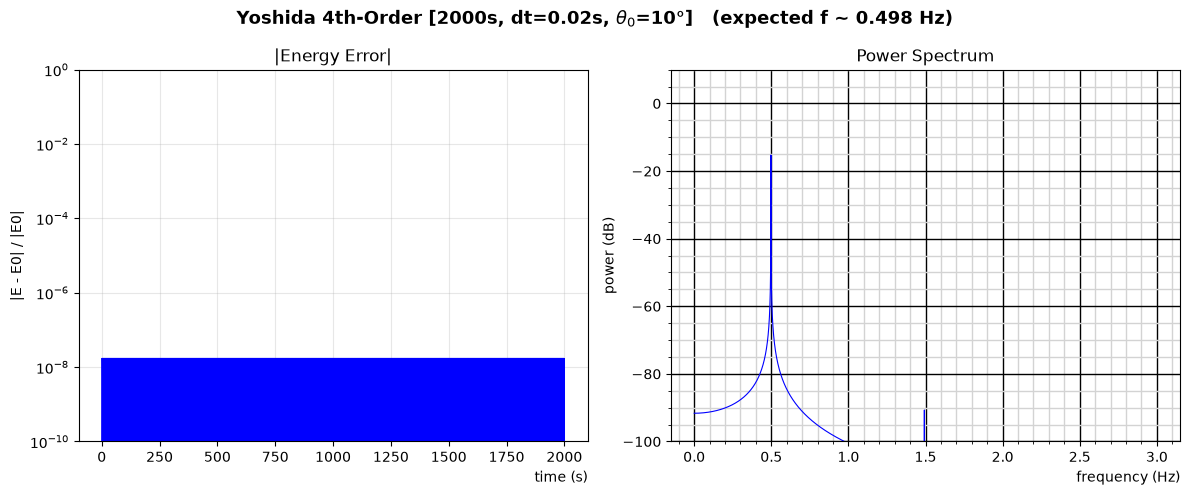

In [10]:
# Cell 10 - Yoshida 4th-order energy error and power spectrum

name = "Yoshida 4th-Order"
t, abs_energy_error, freqs, power, power_db, color = fft_results[name]

fig, (ax_err, ax_fft) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"{name} [{t_final_fft}s, dt={dt_fft}s, "
    rf"$\theta_0$={np.rad2deg(theta_fft):.0f}°]"
    f"   (expected f ~ {f_natural:.3f} Hz)",
    fontsize=13,
    fontweight="bold",
)
plot_energy_error(ax_err, t, abs_energy_error, color)
ax_err.set_ylim(err_ylim)
plot_power_spectrum(ax_fft, freqs, power_db, color)
ax_fft.set_ylim(db_min, db_max)
fig.tight_layout()
plt.show()